In [36]:
import pandas as pd
import re
import spacy
import string
from collections import Counter
from nltk.corpus import stopwords
!pip install contractions
!pip install tweet-preprocessor
!pip install 
!pip install stopwordsiso


ERROR: You must give at least one requirement to install (see "pip help install")
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 2.0 MB/s eta 0:00:00


In [101]:
data_train = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/train.csv')

In [102]:
print(data_train.columns)
print(data_train.info())
data_train.dropna(inplace=True)

Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24732 entries, 0 to 24731
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         24732 non-null  object
 1   text           24732 non-null  object
 2   selected_text  24732 non-null  object
 3   sentiment      24732 non-null  object
dtypes: object(4)
memory usage: 773.0+ KB
None


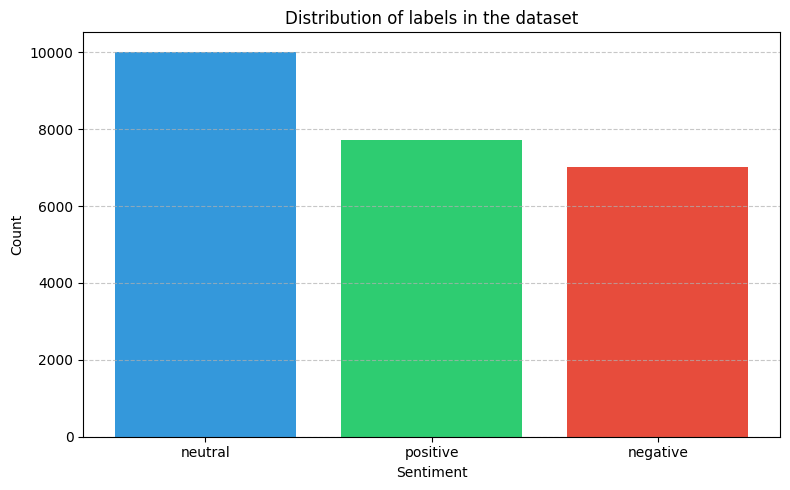

In [105]:
import pandas as pd
import matplotlib.pyplot as plt

# Supponiamo che il tuo dataframe si chiami df
# df = pd.read_csv('tuo_file.csv')  # se stai leggendo da un file

# Esempio dei dati (simulazione):
# sentiment values might be: 'positive', 'negative', 'neutral'

# Calcola la distribuzione dei sentiment
sentiment_counts = data_train['sentiment'].value_counts()

# Colori custom per ogni sentiment
custom_colors = {
    'positive': '#2ecc71',  # verde
    'negative': '#e74c3c',  # rosso
    'neutral':  '#3498db'   # blu
}

# Crea il grafico a barre
plt.figure(figsize=(8, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values,
        color=[custom_colors[sent] for sent in sentiment_counts.index])
plt.title('Distribution of labels in the dataset')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [47]:
def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

In [48]:
data_train['text'] = data_train['text'].apply(lambda x:clean_text(x))

In [49]:
data_train['temp_list'] = data_train['text'].apply(lambda x:str(x).split())
top = Counter([item for sublist in data_train['temp_list'] for item in sublist])
temp = pd.DataFrame(top.most_common(20))
temp.columns = ['Common_words','count']
temp.style.background_gradient(cmap='Greys')

,Common_words,count
0,i,11792
1,to,8993
2,the,8059
3,a,6074
4,my,4966
5,and,4508
6,you,4336
7,it,3667
8,is,3557
9,in,3379


In [50]:
import stopwordsiso as stopwords
def remove_stopword(x):
    return [y for y in x if y not in stopwords.words('english')]
def remove_s(x):
    stop_words = stopwords.stopwords("en")
    return [word for word in x if word not in stop_words]

data_train['temp_list'] = data_train['temp_list'].apply(lambda x:remove_s(x))

# Output: ['example', 'sentence', 'stop', 'words']

In [51]:
# Showing Most Freq. Words After removing Stop Words
top = Counter([item for sublist in data_train['temp_list'] for item in sublist])
temp = pd.DataFrame(top.most_common(20))
temp = temp.iloc[1:,:]
temp.columns = ['Common_words','count']
temp.style.background_gradient(cmap='Blues')

,Common_words,count
1,love,1016
2,happy,872
3,time,852
4,lol,852
5,night,662
6,mothers,644
7,hope,529
8,morning,506
9,haha,502
10,fun,475


In [52]:
Positive_sent = data_train[data_train['sentiment']=='positive']
Negative_sent = data_train[data_train['sentiment']=='negative']
Neutral_sent = data_train[data_train['sentiment']=='neutral']

In [63]:
# Showing Most Freq. Words After removing Stop Words (Postive)
top = Counter([item for sublist in Positive_sent['temp_list'] for item in sublist])
temp_positive = pd.DataFrame(top.most_common(20))
temp_positive.columns = ['Common_words','count']
temp_positive.style.background_gradient(cmap='Greens')

,Common_words,count
0,day,1100
1,love,790
2,happy,750
3,mothers,563
4,hope,359
5,fun,311
6,nice,298
7,lol,297
8,night,286
9,morning,257


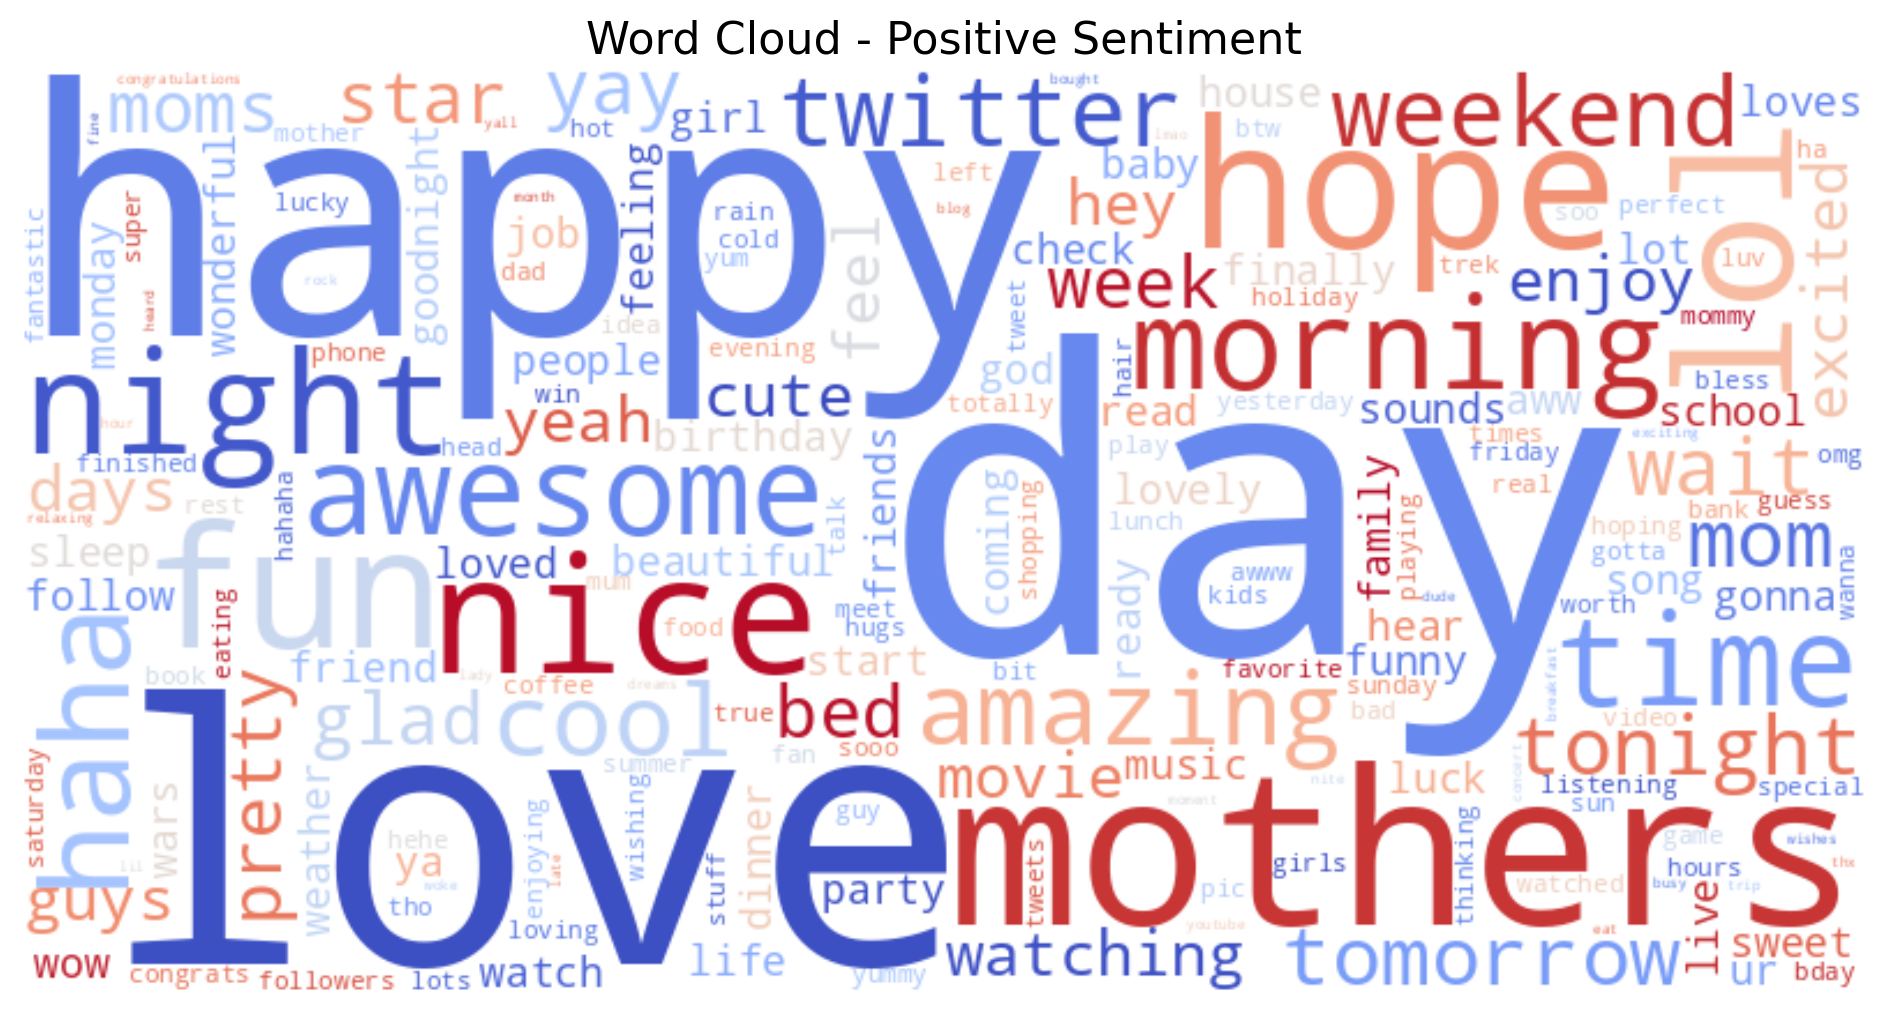

In [65]:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Genera una stringa da tutti i termini presenti nel Counter
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='coolwarm_r').generate_from_frequencies(top)

# Visualizza la Word Cloud
plt.figure(figsize=(12, 6), dpi=200)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Sentiment', fontsize=16)
plt.show()


In [66]:
# Showing Most Freq. Words After removing Stop Words (Negative)
top = Counter([item for sublist in Negative_sent['temp_list'] for item in sublist])
temp_negative = pd.DataFrame(top.most_common(20))
temp_negative = temp_negative.iloc[1:,:]
temp_negative.columns = ['Common_words','count']
temp_negative.style.background_gradient(cmap='Reds')

,Common_words,count
1,day,295
2,bad,284
3,feel,264
4,hate,243
5,time,209
6,sick,189
7,sucks,162
8,tired,159
9,gonna,150
10,lol,141


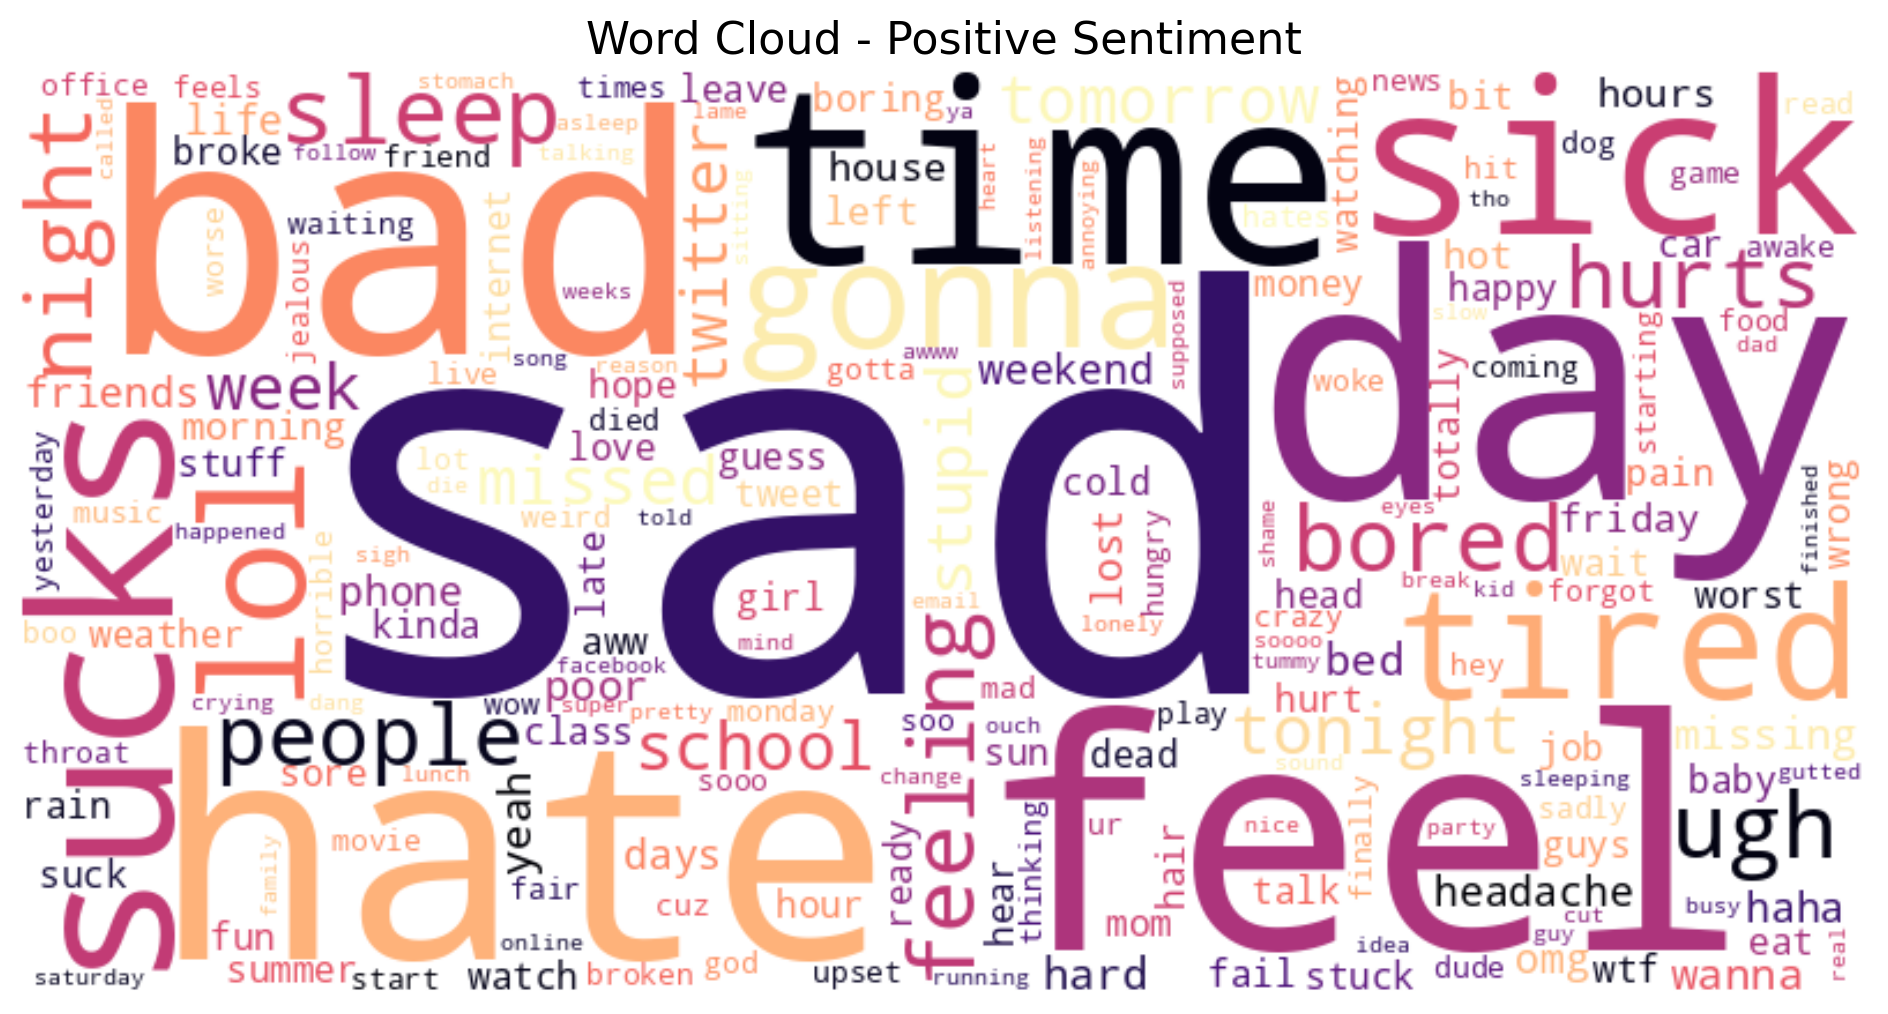

In [68]:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Genera una stringa da tutti i termini presenti nel Counter
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma_r').generate_from_frequencies(top)

# Visualizza la Word Cloud
plt.figure(figsize=(12, 6), dpi=200)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Sentiment', fontsize=16)
plt.show()

In [ ]:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Genera una stringa da tutti i termini presenti nel Counter
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate_from_frequencies(top)

# Visualizza la Word Cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Sentiment', fontsize=16)
plt.show()


In [69]:
# Showing Most Freq. Words After removing Stop Words (Neural)
top = Counter([item for sublist in Neutral_sent['temp_list'] for item in sublist])
temp_neutral = pd.DataFrame(top.most_common(20))
temp_neutral = temp_neutral.loc[1:,:]
temp_neutral.columns = ['Common_words','count']
temp_neutral.style.background_gradient(cmap='Blues')

,Common_words,count
1,lol,414
2,time,387
3,night,245
4,twitter,200
5,tomorrow,194
6,yeah,192
7,haha,192
8,morning,184
9,love,182
10,week,160


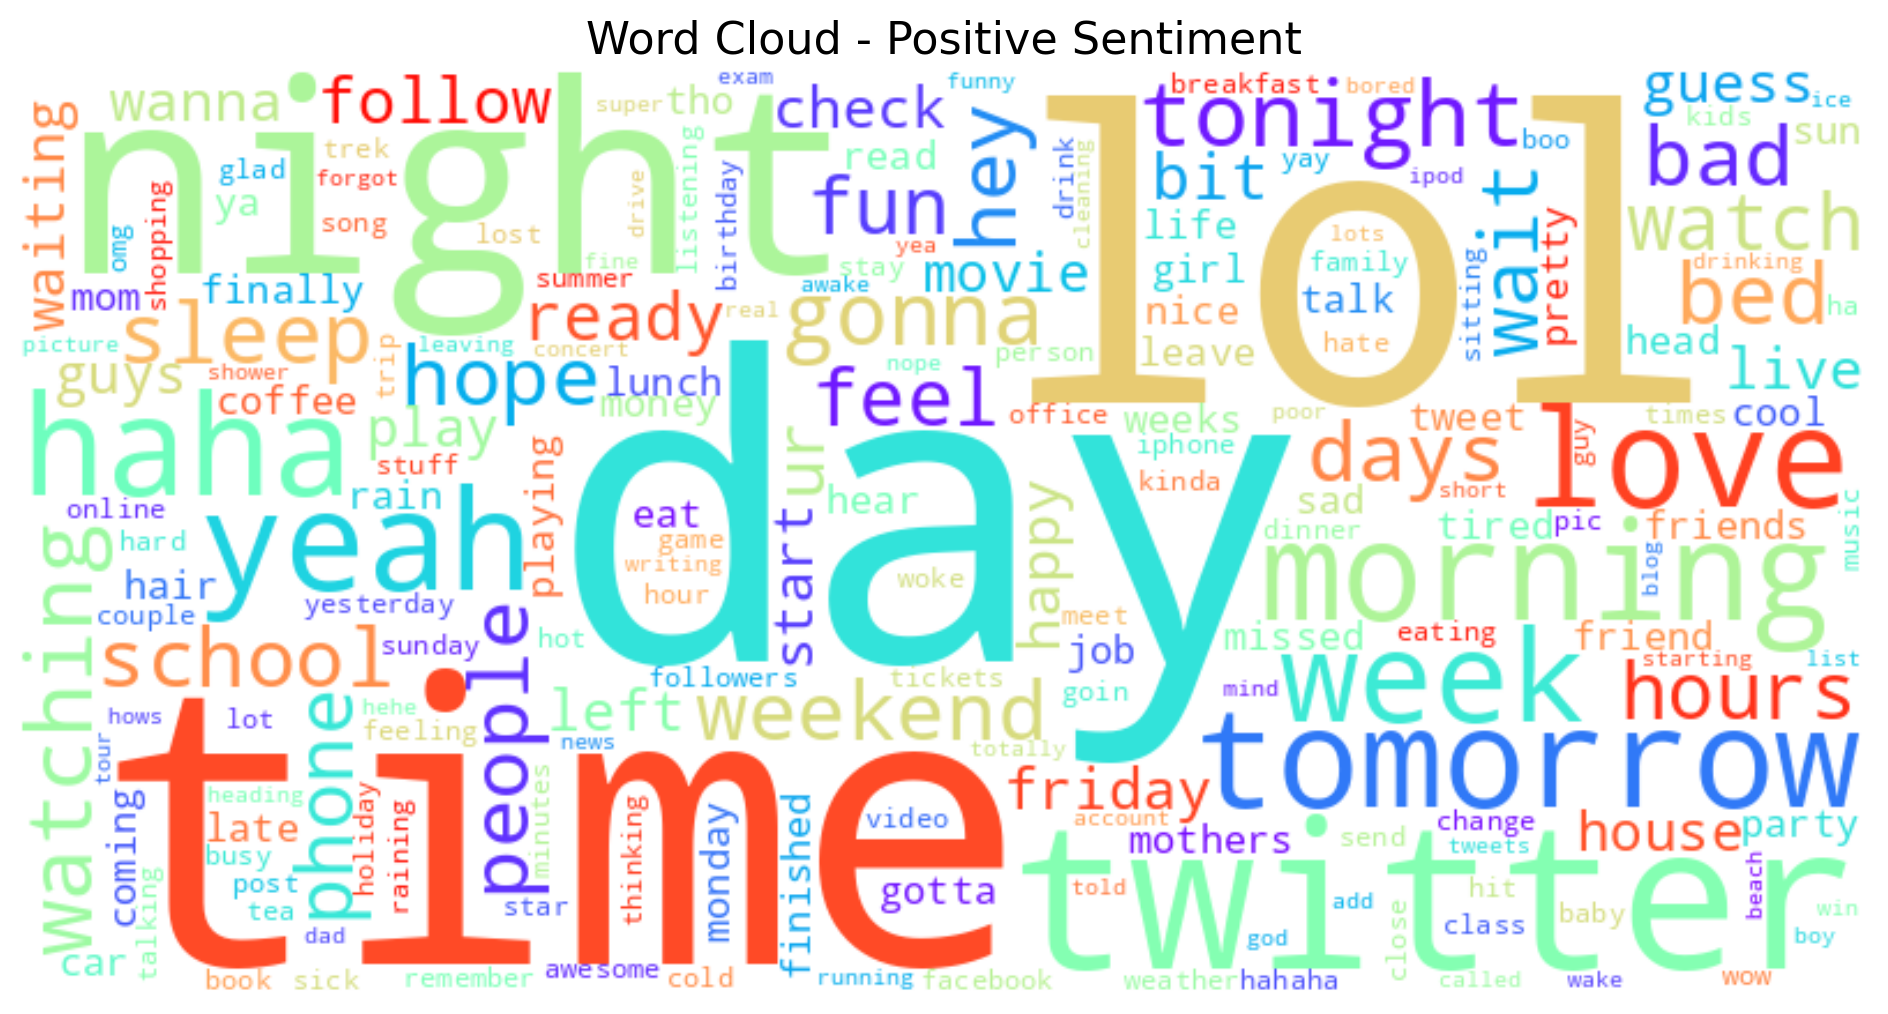

In [70]:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Genera una stringa da tutti i termini presenti nel Counter
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='rainbow_r').generate_from_frequencies(top)

# Visualizza la Word Cloud
plt.figure(figsize=(12, 6), dpi=200)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Sentiment', fontsize=16)
plt.show()

In [230]:
# Carica il modello inglese
#nlp = spacy.load("en_core_web_sm")

#def tokenize_and_lemmatize(text):
#    doc = nlp(text)
#    return [
#        token.lemma_.lower()
#        for token in doc
#        if token.is_alpha and not token.is_stop
#    ]

#data_train['token'] = data_train['text'].apply(tokenize_and_lemmatize)

In [231]:
#print(data_train[['text', 'token']])

In [232]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [209]:
import re
import string
import emoji
import contractions
import preprocessor as p
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag

# Inizializza risorse globali
stop_words = set(stopwords.words('english'))
stop_words.discard("not")  # Mantieni 'not'
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
translator = str.maketrans('', '', string.punctuation)

# Funzione per mappare i POS per WordNetLemmatizer
def get_wordnet_pos(word):
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN,
                "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def preprocess_tweet_full(row):
    text = row['text']
    
    # 1. Pulisce elementi Twitter (link, mention, ecc.)
    text = re.sub(r"http\S+|www.\S+", "", text)         # Rimuove URL
    text = re.sub(r"@\w+", "", text)                   # Rimuove mention
    text = re.sub(r"#\w+", "", text)                   # Rimuove hashtag
    
    # 2. Emoji in testo
    text = emoji.demojize(text)
    
    # 3. Minuscolo
    text = text.lower()
    
    # 4. Correzione contrazioni
    text = ' '.join(contractions.fix(word) for word in text.split())
    
    # 5. Rimuove punteggiatura, numeri e normalizza spazi
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 6. Tokenizza
    tokens = word_tokenize(text)
    
    # 7. Rimuove stopwords (eccetto "not") e parole troppo corte
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    # 8a. Applica stemming
    tokens_stemmed = [stemmer.stem(word) for word in tokens]

    # 8b. Applica lemmatizzazione con POS tagging
    tokens_lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens]
    
    # 9. Restituisce entrambe le versioni
    return {
        'tokens_stemmed': tokens_stemmed,
        'tokens_lemmatized': tokens_lemmatized
    }


In [212]:
import re
import string
import emoji
import contractions
import preprocessor as p
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from textblob import Word
from wordsegment import load, segment
from ekphrasis.dicts.emoticons import emoticons

# Inizializza risorse globali
stop_words = set(stopwords.words('english'))
stop_words.discard("not")  # Mantieni 'not'
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
translator = str.maketrans('', '', string.punctuation)

# Carica modello wordsegment (una sola volta)
load()

# Funzione per normalizzare ripetizioni eccessive (max 2 ripetizioni)
def normalize_repeats(word):
    return re.sub(r'(.)\1{2,}', r'\1\1', word)  # es: coooool -> coool

# Funzione per mappare i POS per WordNetLemmatizer
def get_wordnet_pos(word):
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN,
                "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def preprocess_tweet_full(row):
    text = row['text']
    
    # 1. Pulisce elementi Twitter (link, mention, ecc.)
    text = re.sub(r"http\S+|www.\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    
    # 2. Emoji in testo
    text = emoji.demojize(text)
    
    # 3. Minuscolo
    text = text.lower()
    
    # 4. Correzione contrazioni
    text = ' '.join(contractions.fix(word) for word in text.split())
    
    # 5. Rimuove punteggiatura, numeri e normalizza spazi
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 6. Tokenizza
    tokens = word_tokenize(text)
    
    # 7. Rimuove stopwords (eccetto "not") e parole troppo corte
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    # 8. Segmenta token concatenati con wordsegment
    segmented_tokens = []
    for token in tokens:
        parts = segment(token)
        segmented_tokens.extend(parts)
    
    # 9. Normalizza ripetizioni eccessive
    normalized_tokens = [normalize_repeats(token) for token in segmented_tokens]
    
    # 9. Corregge ortografia di ogni token con TextBlob
    corrected_tokens = []
    for token in segmented_tokens:
        w = Word(token)
        corrected = w.correct()
        corrected_tokens.append(str(corrected))
    
    # 11a. Stemming
    tokens_stemmed = [stemmer.stem(word) for word in corrected_tokens]
    
    # 11b. Lemmatizzazione con POS tagging
    tokens_lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in corrected_tokens]
    
    # 12. Restituisce entrambe le versioni
    return {
        'tokens_stemmed': tokens_stemmed,
        'tokens_lemmatized': tokens_lemmatized
    }

In [234]:
!pip install ekphrasis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.8/83.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00


In [236]:
#data_train[['stemmed', 'lemmatized']] = data_train.apply(
#    lambda row: pd.Series(preprocess_tweet_full(row)), axis=1
#)

#print(data_train[['text', 'stemmed', 'lemmatized']])

                                                    text stemmed lemmatized
0                            good luck with your auction      []         []
1      Hmm..You can`t judge a book by looking at its ...      []         []
2       Hello, yourself. Enjoy London. Watch out for ...      []         []
3             We can`t even call you from belgium  sucks      []         []
4                                     not so good mood..      []         []
...                                                  ...     ...        ...
24727  Getting closer to logging in. My left hand is ...      []         []
24728                             I`m drawning in emails      []         []
24729        Oh Duh....I see that now .....thank you....      []         []
24730   my internet in like 9th grade was so fast, it...      []         []
24731   Content content content .... gah! Story of my...      []         []

[24732 rows x 3 columns]


In [214]:
data_train.to_csv('data_train_pre.csv', index=False)
data_train.to_json('data_train_pre.json', orient='records')

In [3]:
data_train = pd.read_csv('/kaggle/working/data_train_pre.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/data_train_pre.csv'

In [7]:
import pandas as pd
import ast
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

data_train = pd.read_csv('/kaggle/input/data-train-pre/data_train_pre.csv')

data_train["lemmatized"] = data_train["lemmatized"].apply(ast.literal_eval)

# Filtra via le righe con lista vuota in "lemmatized"
data_train = data_train[data_train["lemmatized"].apply(lambda x: len(x) > 0)].reset_index(drop=True)

# Supponiamo che il tuo DataFrame si chiami data_train
# label encoding
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}
data_train["label"] = data_train["sentiment"].map(label2id)

data_train["token"] = data_train["lemmatized"]

data_train.to_csv('data_train_preprocessing.csv', index=False)
data_train.to_csv('data_train_preprocessing.json', index=False)

In [139]:
data_train = pd.read_csv('/kaggle/working/data_train_preprocessing.csv')

In [140]:
data_train["token"] = data_train["token"].apply(ast.literal_eval)
#data_train = data_train[data_train["token"].apply(len) > 1]
data_train['token'] = data_train["token"].apply(lambda x: " ".join(x))

In [141]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score

# Definisci la pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('logreg', LogisticRegression(max_iter=1000))
])

# Parametri per la grid search
param_grid = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'logreg__C': [0.01, 0.1, 1, 10],
    'logreg__solver': ['liblinear', 'lbfgs'],
}

# Dati
X = data_train["token"]
y = data_train["label"]

# Train/validation/test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# GridSearch con macro F1
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

# Fit sul training set
grid_search.fit(X_train, y_train)

# Migliori parametri
print("Best parameters:", grid_search.best_params_)

# Valutazione sul test set
y_pred = grid_search.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label2id.keys()))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'logreg__C': 1, 'logreg__solver': 'liblinear', 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Test accuracy: 0.6974289580514208
              precision    recall  f1-score   support

    negative       0.73      0.62      0.67      1050
     neutral       0.64      0.76      0.69      1489
    positive       0.77      0.69      0.73      1156

    accuracy                           0.70      3695
   macro avg       0.71      0.69      0.70      3695
weighted avg       0.71      0.70      0.70      3695

[CV] END logreg__C=0.01, logreg__solver=liblinear, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time=   0.3s
[CV] END logreg__C=0.01, logreg__solver=liblinear, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time=   0.3s
[CV] END logreg__C=0.01, logreg__solver=liblinear, tfidf__max_features=5000, tfidf__ngram_range=(1, 2); total time=   0.7s
[CV] END logreg__C=0.01, logr

In [112]:
#data_train["lemmatized_text"] = data_train["lemmatized"].apply(lambda x: " ".join(x))

# TF-IDF vectorization sulla colonna 'text'
#tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english')
#X = tfidf.fit_transform(data_train["token"])
#y = data_train["label"]

# Prima divisione: 70% train, 30% temp
#X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Seconda divisione: 15% validation, 15% test (cioè metà di X_temp)
#X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Logistic Regression
#model = LogisticRegression(max_iter=1000)
#model.fit(X_train, y_train)

# Prediction
#y_pred = model.predict(X_test)

# Evaluation
#print("Accuracy:", accuracy_score(y_test, y_pred))
#print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label2id.keys()))

Accuracy: 0.687956698240866

Classification Report:
               precision    recall  f1-score   support

    negative       0.73      0.59      0.65      1050
     neutral       0.62      0.77      0.69      1489
    positive       0.79      0.67      0.72      1156

    accuracy                           0.69      3695
   macro avg       0.71      0.68      0.69      3695
weighted avg       0.70      0.69      0.69      3695



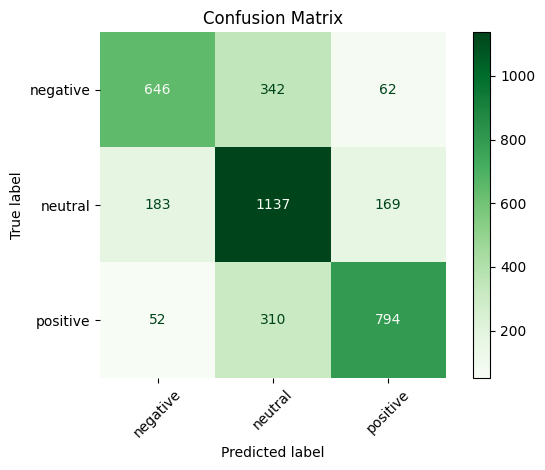

In [143]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calcolo della conofusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualizzazione
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label2id.keys())
fig, ax = plt.subplots()
disp.plot(cmap='Greens', xticks_rotation=45, ax=ax)

# Rimuovi i bordi neri attorno all'asse
for spine in ax.spines.values():
    spine.set_visible(False)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [137]:
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import f1_score, classification_report


clf = LinearSVC(class_weight="balanced", random_state=42)
clf = SVC(class_weight="balanced", kernel = 'rbf')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label2id.keys()))

Accuracy: 0.6871447902571042

Classification Report:
               precision    recall  f1-score   support

    negative       0.70      0.62      0.66      1050
     neutral       0.63      0.74      0.68      1489
    positive       0.78      0.67      0.72      1156

    accuracy                           0.69      3695
   macro avg       0.70      0.68      0.69      3695
weighted avg       0.70      0.69      0.69      3695



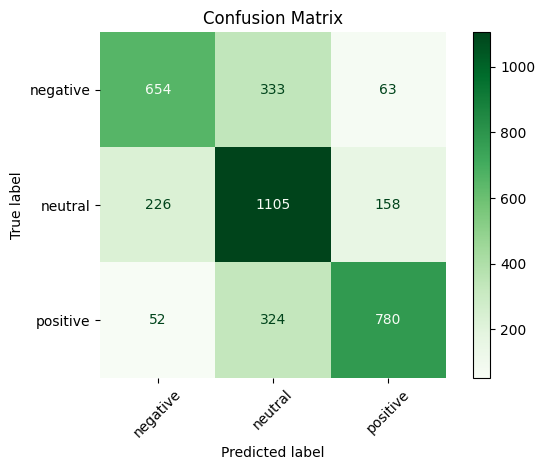

In [138]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calcolo della confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualizzazione
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label2id.keys())
fig, ax = plt.subplots()
disp.plot(cmap='Greens', xticks_rotation=45, ax=ax)

# Rimuovi i bordi neri attorno all'asse
for spine in ax.spines.values():
    spine.set_visible(False)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
